# BFE Potentials in $\texttt{streamsculptor}$

This notebook demonstrates how to use `bfeax`, a Jax-based basis function expansion code, to construct full featured streamsculptor potentials via the `BFEPotential` module in streamsculptor.

This module is a wrapper of the bfeax code.


**Requirements**
```bash
pip install git+https://github.com/jnibauer/bfeax.git
```

In [33]:
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from streamsculptor.bfe import BFEPotential
from streamsculptor.potential import Potential_Combine
import streamsculptor as ssc




## 1. Build a triaxial NFW potential

We use `BFEPotential.from_spheroid` with the spheroidal profile:

$$\rho(\tilde{r}) = \rho_0 \left(\frac{\tilde{r}}{a}\right)^{-\gamma} \left[1 + \left(\frac{\tilde{r}}{a}\right)^\alpha\right]^{(\gamma-\beta)/\alpha}$$

where $\tilde{r} = \sqrt{x^2 + (y/p)^2 + (z/q)^2}$ is the spheroidal radius.

For an NFW profile: $\alpha=1,\ \beta=3,\ \gamma=1$.



In [56]:
# Triaxial NFW: scale radius a=1, axis ratios p=0.9 (y), q=0.7 (z)
# symmetry="triaxial" skips modes that vanish by octant symmetry (~3x fewer modes)

pot_bfe = BFEPotential.from_spheroid(
    rho0=1e9, alpha=1.0, beta=3.0, gamma=1.0, a=1.0,
    p=0.9, q=0.4,
    r_min=1e-2, r_max=300.0,
    n_r=128, l_max=8,
    #symmetry="triaxial", # Spheroid autodetecs symmetry, so this is optional. But for more general models it is good to specify!
)

print("BFEAxPotential built successfully.")
print(f"Phi at (1, 0, 0): {pot_bfe.potential(jnp.array([10., 0., 0.]), 0.):.6f}")
print(f"Phi at (0, 1, 0): {pot_bfe.potential(jnp.array([0., 1., 0.]), 0.):.6f}")
print(f"Phi at (0, 0, 1): {pot_bfe.potential(jnp.array([0., 0., 1.]), 0.):.6f}")

BFEAxPotential built successfully.
Phi at (1, 0, 0): -0.005642
Phi at (0, 1, 0): -0.017479
Phi at (0, 0, 1): -0.015981


## 2. Check the triaxiality

The BFE potential should be anisotropic — the three principal axes should give different values at the same radius.

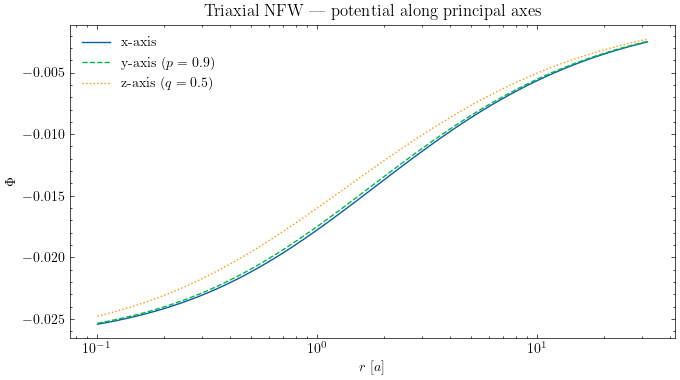

In [57]:
r_test = jnp.logspace(-1, 1.5, 60)

phi_x = jax.vmap(lambda r: pot_bfe.potential(jnp.array([r, 0., 0.]), 0.))(r_test)
phi_y = jax.vmap(lambda r: pot_bfe.potential(jnp.array([0., r, 0.]), 0.))(r_test)
phi_z = jax.vmap(lambda r: pot_bfe.potential(jnp.array([0., 0., r]), 0.))(r_test)

plt.figure(figsize=(7, 4))
plt.plot(r_test, phi_x, label="x-axis")
plt.plot(r_test, phi_y, label="y-axis  ($p=0.9$)", ls="--")
plt.plot(r_test, phi_z, label="z-axis  ($q=0.5$)", ls=":")
plt.xscale("log")
plt.xlabel("$r$ [$a$]")
plt.ylabel("$\\Phi$")
plt.title("Triaxial NFW — potential along principal axes")
plt.legend()
plt.tight_layout()
plt.show()

## 3. Plot potential and density contours. Compare reconstructed density to true density.

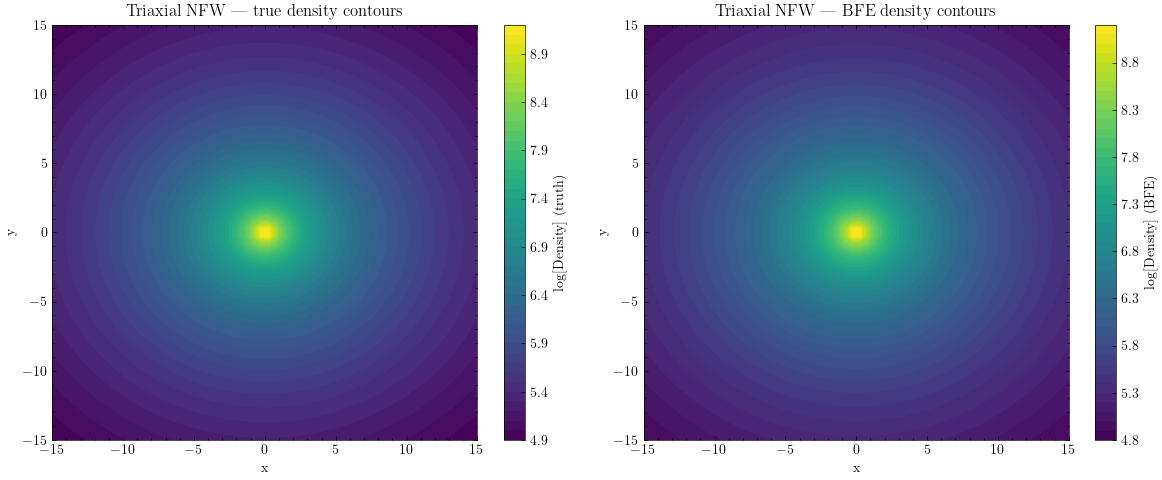

In [61]:
# plot density contours and compare to the truth
# truth: The density profile is:
 #           rho(r) = rho0 * (r/a)^{-gamma} * [1 + (r/a)^alpha]^{(gamma-beta)/alpha}
#           where r^2 = x^2 + (y/p)^2 + (z/q)^2
x = jnp.linspace(-15, 15, 60)
y = jnp.linspace(-15, 15, 60)
X, Y = jnp.meshgrid(x, y)
Z = jnp.zeros_like(X)
R = jnp.sqrt(X**2 + (Y/0.9)**2 + (Z/0.4)**2)

rho_truth = 1e9 * (R)**(-1) * (1 + R)**(-2)
rho_bfe = jax.vmap(lambda x, y: pot_bfe.density(jnp.array([x, y, 0.]), 0.))(X.flatten(), Y.flatten()).reshape(X.shape)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.contourf(X, Y, np.log10(rho_truth), levels=50, cmap="viridis")
plt.colorbar(label="log[Density] (truth)")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Triaxial NFW — true density contours")
plt.subplot(1, 2, 2)
plt.contourf(X, Y, np.log10(rho_bfe), levels=50, cmap="viridis")
plt.colorbar(label="log[Density] (BFE)")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Triaxial NFW — BFE density contours")
plt.tight_layout()
plt.show()





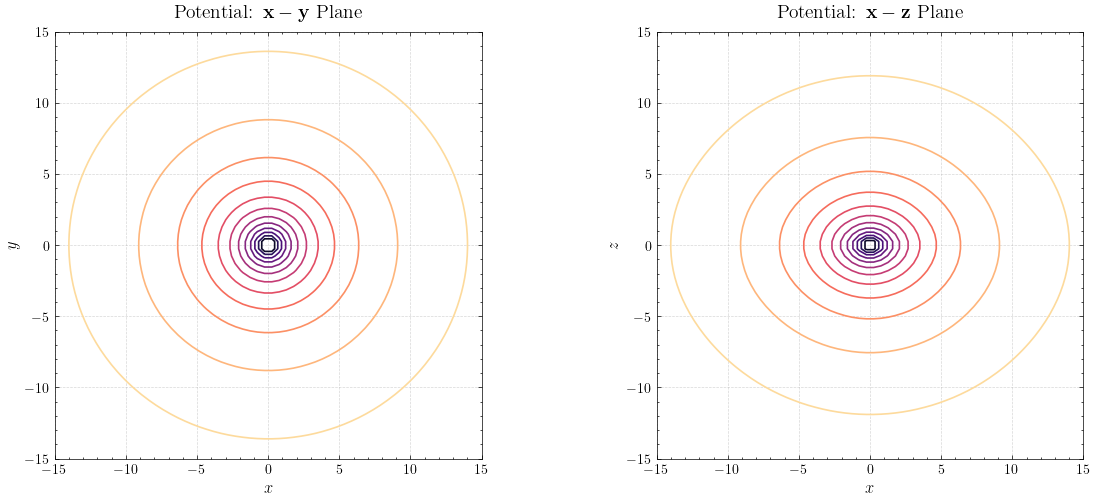

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, constrained_layout=True)

contour_kwargs = dict(levels=15, cmap="magma", linewidths=1.2)

cs1 = axes[0].contour(X, Y, phi_bfe_xy, **contour_kwargs)
axes[0].set_title(r"Potential: $\mathbf{x-y}$ Plane", fontsize=14, pad=10)
axes[0].set_xlabel("$x$", fontsize=12)
axes[0].set_ylabel("$y$", fontsize=12)

cs2 = axes[1].contour(X, Z, phi_bfe_xz, **contour_kwargs)
axes[1].set_title(r"Potential: $\mathbf{x-z}$ Plane", fontsize=14, pad=10)
axes[1].set_xlabel("$x$", fontsize=12)
axes[1].set_ylabel("$z$", fontsize=12)

for ax in axes:
    ax.set_aspect('equal') # Forces the physical scale to be the same
    ax.grid(True, linestyle='--', alpha=0.5)


## 4. Integrate an orbit

A `BFEPotential` is a standard StreamSculptor `Potential`, so orbit integration works out of the box.

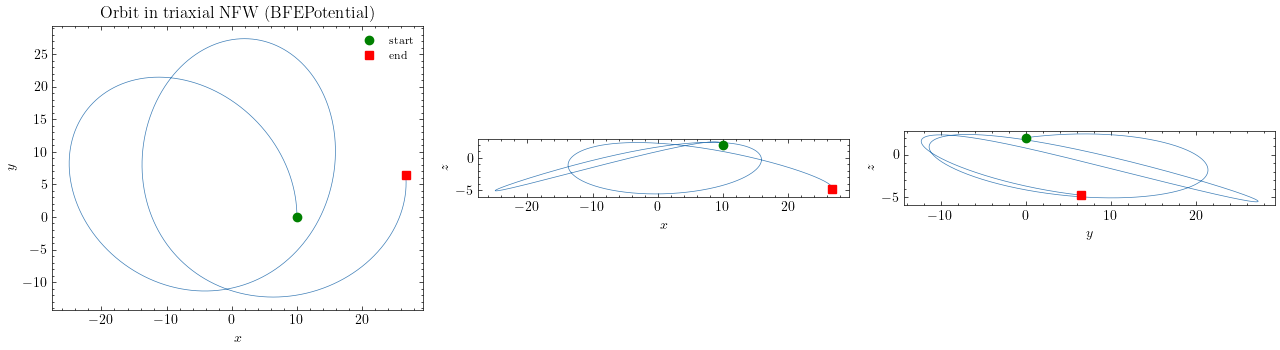

In [81]:
# Initial conditions: position [kpc-like] + velocity [kpc/Myr-like]
w0 = jnp.array([10.0, 0.0, 2.0,   # x, y, z
                  0.0, 0.08, 0.01]) # vx, vy, vz

ts = jnp.linspace(0.0, 5000.0, 5000)   # time in Myr

orbit = pot_bfe.integrate_orbit(w0, t0=ts[0], t1=ts[-1], ts=ts)

xyz = orbit.ys[:, :3]  # positions

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
labels = [("x", "y"), ("x", "z"), ("y", "z")]
idx    = [(0, 1), (0, 2), (1, 2)]

for ax, (xl, yl), (i, j) in zip(axes, labels, idx):
    ax.plot(xyz[:, i], xyz[:, j], lw=0.5, alpha=0.8)
    ax.plot(*xyz[0, [i, j]], "go", ms=6, label="start")
    ax.plot(*xyz[-1, [i, j]], "rs", ms=6, label="end")
    ax.set_xlabel(f"${xl}$")
    ax.set_ylabel(f"${yl}$")
    ax.set_aspect("equal")

axes[0].legend(fontsize=8)
axes[0].set_title("Orbit in triaxial NFW (BFEPotential)")
plt.tight_layout()
plt.show()

## 5. Generate a stellar stream

This is identical to how you would use any other `Potential`

In [82]:
# Progenitor initial conditions
prog_w0 = jnp.array([10.0, 0.0, 2.0,
                       0.0, 0.08, 0.01])

# Satellite mass and scale radius
M_sat = 1e5    # Msun
r_s   = 0.1    # scale radius (same units as potential)

ts_stream = jnp.linspace(-3000.0, 0.0, 1000)   # integrate backwards in time

stream = pot_bfe.gen_stream_vmapped(
    prog_w0=prog_w0,
    Msat=M_sat, 
    ts=ts_stream,
    seed_num=0,
)

lead  = stream[0]   # leading arm
trail = stream[1]   # trailing arm

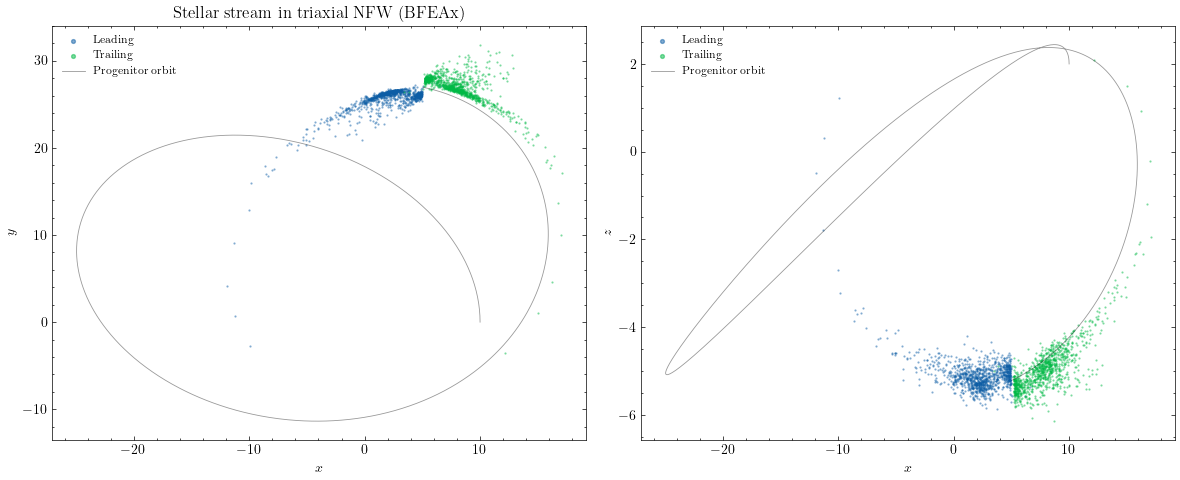

In [83]:
# Integrate the progenitor orbit for plotting
prog_orbit = pot_bfe.integrate_orbit(prog_w0, t0=ts_stream[0], t1=ts_stream[-1], ts=ts_stream)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (i, j, xl, yl) in zip(axes,
    [(0, 1, "x", "y"), (0, 2, "x", "z")]):

    ax.scatter(lead[:, i],  lead[:, j],  s=0.3, c="C0", alpha=0.5, label="Leading")
    ax.scatter(trail[:, i], trail[:, j], s=0.3, c="C1", alpha=0.5, label="Trailing")
    ax.plot(prog_orbit.ys[:, i], prog_orbit.ys[:, j],
            "k-", lw=0.6, alpha=0.4, label="Progenitor orbit")
    #ax.plot(prog_w0[i], prog_w0[j], "k*", ms=10, label="Progenitor (now)")
    ax.set_xlabel(f"${xl}$")
    ax.set_ylabel(f"${yl}$")
    ax.legend(markerscale=5, fontsize=8)

axes[0].set_title("Stellar stream in triaxial NFW (BFEAx)")
plt.tight_layout()
plt.show()

## 6. Combine with other streamsculptor potentials

`BFEAxPotential` composes naturally with `Potential_Combine` — e.g. add a disk or bulge on top of the BFE halo.

In [84]:
from streamsculptor.potential import MiyamotoNagaiDisk, HernquistPotential

# NFW halo (BFE) + Miyamoto-Nagai disk + Hernquist bulge
disk  = MiyamotoNagaiDisk(m=5e10, a=3.0, b=0.3,units=ssc.usys)
bulge = HernquistPotential(m=1e10, r_s=1.0,units=ssc.usys)

pot_mw = Potential_Combine([pot_bfe, disk, bulge],units=ssc.usys)

# Verify the combined potential evaluates correctly
xyz_test = jnp.array([8.0, 0.0, 0.0])
print(f"BFE halo alone : {pot_bfe.potential(xyz_test, 0.):.4f}")
print(f"Combined MW    : {pot_mw.potential(xyz_test, 0.):.4f}")
print(f"Acceleration   : {pot_mw.acceleration(xyz_test, 0.)}")

BFE halo alone : -0.0065
Combined MW    : -0.0375
Acceleration   : [-3.84538047e-03 -0.00000000e+00 -2.18770551e-20]


## 7. Build from an arbitrary density function

You're not limited to spheroid profiles. Any JAX-traceable `rho(x, y, z)` works.

In [85]:
def my_density(x, y, z):
    """A custom triaxial density — e.g. two-power-law with hand-tuned axis ratios."""
    r_tilde = jnp.sqrt(x**2 + (y / 0.85)**2 + (z / 0.6)**2)
    return 1.0 / (r_tilde * (1.0 + r_tilde)**2)   # NFW-like radial profile

pot_custom = BFEPotential.from_density(
    my_density,
    r_min=1e-2, r_max=300.0,
    n_r=128, l_max=8,
    symmetry="triaxial",
)

print(f"Custom BFE potential at (2, 1, 0.5): {pot_custom.potential(jnp.array([2., 1., 0.5]), 0.):.16f}")

Custom BFE potential at (2, 1, 0.5): -0.0000000000172631
